# Task 5: Feature Engineering & PCA

**Dataset:** Seaborn `tips` dataset (built-in, no download/path issues)

**Steps:**
1. Load and validate data
2. Standard scaling (numeric features)
3. One-hot encoding (categorical features)
4. PCA to reduce dimensionality
5. Visualize explained variance and principal components


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', None)

## Config

In [2]:
# --- Config: all paths, column names, and parameters defined here (no hardcoding below) ---
PROJECT_ROOT = Path.cwd()
VIS_DIR = PROJECT_ROOT / "visualizations"
VIS_DIR.mkdir(exist_ok=True)

DATASET_NAME = "tips"
NUMERIC_FEATURES = ["total_bill", "tip", "size"]
CATEGORICAL_FEATURES = ["sex", "smoker", "day", "time"]
TARGET_COLUMN = None  # unsupervised task, no target needed

N_PCA_COMPONENTS = 2
RANDOM_STATE = 42

EXPLAINED_VAR_PLOT_PATH = VIS_DIR / "explained_variance.png"
PCA_SCATTER_PLOT_PATH = VIS_DIR / "pca_scatter.png"


## Load & Validate Data

In [3]:
def load_data(dataset_name: str) -> pd.DataFrame:
    """Load dataset by name (built-in seaborn dataset, avoids path issues)."""
    df = sns.load_dataset(dataset_name)
    return df


def validate_data(df: pd.DataFrame, numeric_cols: list, categorical_cols: list) -> None:
    """Post-load validation checks."""
    expected_cols = set(numeric_cols) | set(categorical_cols)
    assert expected_cols.issubset(df.columns), f"Missing expected columns: {expected_cols - set(df.columns)}"
    assert df[numeric_cols + categorical_cols].isnull().sum().sum() == 0, "Unexpected nulls found"
    for col in numeric_cols:
        assert pd.api.types.is_numeric_dtype(df[col]), f"{col} is not numeric"
    for col in categorical_cols:
        assert df[col].dtype.name in ("category", "object"), f"{col} is not categorical"
    print(f"Validation passed: {df.shape[0]} rows, {df.shape[1]} columns, no nulls.")


df = load_data(DATASET_NAME)
validate_data(df, NUMERIC_FEATURES, CATEGORICAL_FEATURES)
df.head()

Validation passed: 244 rows, 7 columns, no nulls.


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Feature Engineering: Scaling + One-Hot Encoding

In [4]:
def build_preprocessor(numeric_cols: list, categorical_cols: list) -> ColumnTransformer:
    """Reusable preprocessor: StandardScaler for numeric, OneHotEncoder for categorical."""
    return ColumnTransformer(
        transformers=[
            ("scale", StandardScaler(), numeric_cols),
            ("onehot", OneHotEncoder(drop="first", sparse_output=False), categorical_cols),
        ]
    )


def transform_features(df: pd.DataFrame, preprocessor: ColumnTransformer,
                        numeric_cols: list, categorical_cols: list) -> pd.DataFrame:
    """Fit-transform features and return a labeled DataFrame."""
    X = preprocessor.fit_transform(df[numeric_cols + categorical_cols])
    feature_names = preprocessor.get_feature_names_out()
    return pd.DataFrame(X, columns=feature_names, index=df.index)


preprocessor = build_preprocessor(NUMERIC_FEATURES, CATEGORICAL_FEATURES)
X_processed = transform_features(df, preprocessor, NUMERIC_FEATURES, CATEGORICAL_FEATURES)

# Post-transform validation
assert not X_processed.isnull().any().any(), "Nulls introduced during preprocessing"
assert np.isfinite(X_processed.values).all(), "Non-finite values found after preprocessing"
print(f"Processed feature matrix shape: {X_processed.shape}")
X_processed.head()

Processed feature matrix shape: (244, 9)


,scale__total_bill,scale__tip,scale__size,onehot__sex_Male,onehot__smoker_Yes,onehot__day_Sat,onehot__day_Sun,onehot__day_Thur,onehot__time_Lunch
0,-0.314711,-1.439947,-0.600193,0.0,0.0,0.0,1.0,0.0,0.0
1,-1.063235,-0.969205,0.453383,1.0,0.0,0.0,1.0,0.0,0.0
2,0.137780,0.363356,0.453383,1.0,0.0,0.0,1.0,0.0,0.0
3,0.438315,0.225754,-0.600193,1.0,0.0,0.0,1.0,0.0,0.0
4,0.540745,0.443020,1.506958,0.0,0.0,0.0,1.0,0.0,0.0


## Principal Component Analysis

In [5]:
def run_pca(X: pd.DataFrame, n_components: int, random_state: int) -> tuple:
    """Fit PCA and return the model plus transformed components."""
    pca = PCA(n_components=n_components, random_state=random_state)
    components = pca.fit_transform(X)
    return pca, components


pca_model, pca_components = run_pca(X_processed, N_PCA_COMPONENTS, RANDOM_STATE)

explained_var = pca_model.explained_variance_ratio_
print("Explained variance ratio per component:", np.round(explained_var, 4))
print("Total variance retained:", round(explained_var.sum(), 4))

assert pca_components.shape == (X_processed.shape[0], N_PCA_COMPONENTS), "Unexpected PCA output shape"
assert np.isfinite(pca_components).all(), "Non-finite values in PCA output" 

Explained variance ratio per component: [0.5119 0.1271]
Total variance retained: 0.639


## Visualization: Explained Variance

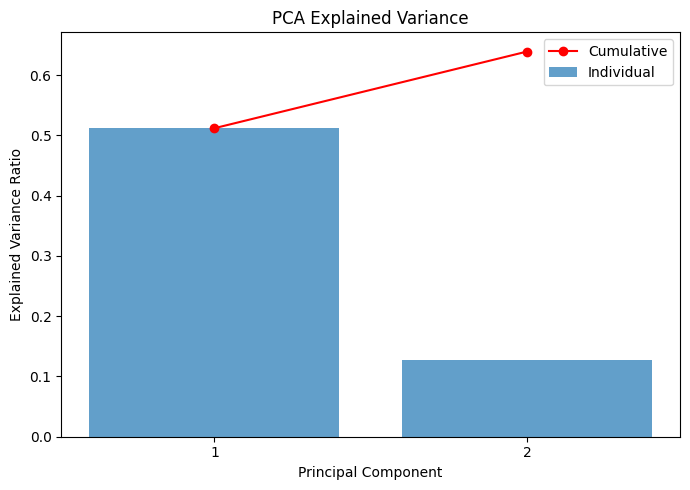

In [6]:
def plot_explained_variance(pca_model: PCA, save_path: Path) -> None:
    """Bar + cumulative line plot of explained variance ratio."""
    ratios = pca_model.explained_variance_ratio_
    cumulative = np.cumsum(ratios)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.bar(range(1, len(ratios) + 1), ratios, alpha=0.7, label="Individual")
    ax.plot(range(1, len(ratios) + 1), cumulative, marker="o", color="red", label="Cumulative")
    ax.set_xlabel("Principal Component")
    ax.set_ylabel("Explained Variance Ratio")
    ax.set_title("PCA Explained Variance")
    ax.set_xticks(range(1, len(ratios) + 1))
    ax.legend()
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()


plot_explained_variance(pca_model, EXPLAINED_VAR_PLOT_PATH)

## Visualization: 2D PCA Projection

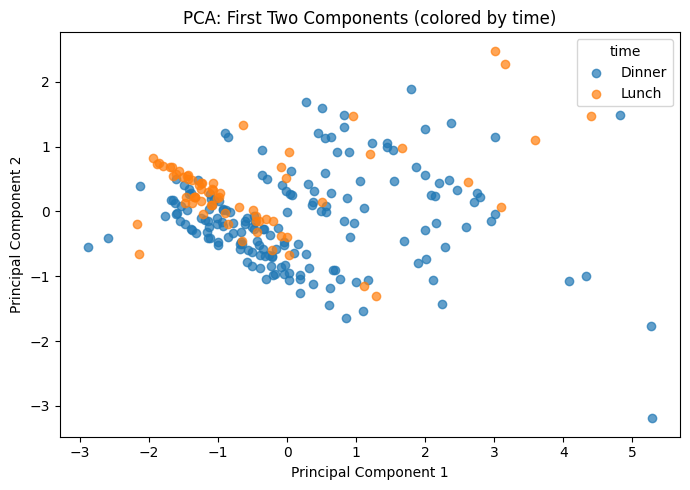

In [7]:
def plot_pca_scatter(components: np.ndarray, hue_labels: pd.Series, save_path: Path) -> None:
    """Scatter plot of the first two principal components, colored by a categorical label."""
    fig, ax = plt.subplots(figsize=(7, 5))
    categories = hue_labels.astype(str).unique()
    for cat in categories:
        mask = hue_labels.astype(str) == cat
        ax.scatter(components[mask, 0], components[mask, 1], label=cat, alpha=0.7)
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.set_title("PCA: First Two Components (colored by time)")
    ax.legend(title="time")
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()


plot_pca_scatter(pca_components, df["time"], PCA_SCATTER_PLOT_PATH)

## Conclusion

- Numeric features (`total_bill`, `tip`, `size`) were standardized with `StandardScaler`.
- Categorical features (`sex`, `smoker`, `day`, `time`) were one-hot encoded with `OneHotEncoder` (first category dropped to avoid multicollinearity).
- PCA reduced the encoded feature space to 2 components, retaining the variance ratio printed above.
- Visualizations saved to the `visualizations/` folder: explained variance plot and 2D PCA scatter plot.
